In [277]:
# 06/2025
# Load distance matrices, generate isomap/Umap
# Join the above generated shape info with Database-specific infomation: patient or control
# verifications
# save the csv file if needed
###########################################################################################
# statistical tests using the data loaded above
#   normality tests for all and by hemisphere
#   T-test or Mann-Whitney U (Wilcoxon ranksum), all together and by separate hemisphere as well
#   plots

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
curRegion = 'Calc'
curRoot = 'C'  # 'C' or 'D'

In [5]:
#######################  Helper function to load patient control info  #########################

def load_patientControlInfo_CADASIL(curRoot, filename="patients_controls_table.csv"):
    """
    Loads and processes the CADASIL info table.

    Parameters
    ----------
    curRoot : str
        Root path where the data is stored.
    filename : str, optional
        Name of the CSV file (default: 'patients_controls_table.csv').

    Returns
    -------
    pd.DataFrames
        Processed CADASIL dataframe with 'subjName' as index and 'Category_num' column.
        Returns None if file not found.
    """
    CADASIL_info_path = rf"{curRoot}:\B_projWIP\proj_CADASIL\{filename}"
    
    try:
        CADASIL_info = pd.read_csv(CADASIL_info_path, index_col=0, header=0, sep=";")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None
    
    # Reset index to make old index 'Subject' a column
    CADASIL_info.reset_index(inplace=True)

    # Step 1: Append '_1' to Subject if it contains '74', '75', or '76'
    CADASIL_info['Subject'] = CADASIL_info['Subject'].astype(str).apply(
        lambda x: x + '_1' if any(substr in x for substr in ['74', '75', '76']) else x
    )
    
    # Step 2: Create 'subjName' and set it as index
    CADASIL_info['subjName'] = (
        'rv_BIOMRI_CADA_001_' +
        CADASIL_info['Subject'].str.replace('-', '_') +
        '_S3_3DT1_mprage_1iso_ipat2'
    )
    CADASIL_info.set_index('subjName', inplace=True)

    # Step 3: Create numeric category
    CADASIL_info['Category_num'] = CADASIL_info['Category'].map({'Control': 0, 'Patient': 1})

    return CADASIL_info

In [47]:
########################  Helper function to filter the distance matrix  ########################

def filterDistance(df, meta, category=None, exclude_str=None):
    """
    Filter a square distance matrix (df) based on metadata and/or index substrings.
    
    Parameters
    ----------
    df : pd.DataFrame
        Square distance matrix with subjName as both index and columns.
    meta : pd.DataFrame
        Metadata dataframe with subjName as index and a 'Category' column.
    category : str, optional
        Category to include (e.g., "Control" or "Patient").
    exclude_str : str, optional
        Substring in subjName to exclude (e.g., "_2_").
    
    Returns
    -------
    pd.DataFrame
        Filtered distance matrix.
    """
    mask = pd.Series(True, index=df.index)

    # Filter by category
    if category is not None:
        allowed_subjects = meta.loc[meta['Category'] == category].index
        mask &= df.index.isin(allowed_subjects)

    # Filter by substring
    if exclude_str is not None:
        mask &= ~df.index.str.contains(exclude_str)

    # Apply symmetric filtering (rows + cols)
    df_filtered = df.loc[mask, mask]
    return df_filtered


In [91]:
#######################################  load distances  #####################################
curTypeAnalysis = 'main_piece_analysis' # 'basic_analysis' or 'main_piece_analysis'  ##  !!!!!!!!   CHANGE  !!!!!!!!

##  reading from the basic analysis, already with _2_ filtered out  ##
distance_path_min = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2\minDist{curRegion}.txt'
distance_path_max = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2\maxDist{curRegion}.txt'

try:
    minDist = pd.read_csv(distance_path_min, index_col=0, header=0)
    maxDist = pd.read_csv(distance_path_max, index_col=0, header=0)    
except FileNotFoundError as e:
    print(f"Error: {e}")

rows, cols = minDist.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 86
Number of columns: 86


In [63]:
##################################### Prepare Patient/Control infomation ####################################
# Note: this is needed to filter the distance matrix
CADASIL_info = load_patientControlInfo_CADASIL(curRoot)

# Start with your processed metadata
df = CADASIL_info.copy()

# First duplicate with "L"
df_L = df.copy()
df_L.index = "L" + df_L.index.astype(str)

# Second duplicate with "flip-R"
df_R = df.copy()
df_R.index = "flip-R" + df_R.index.astype(str)

# Concatenate all together
CADASIL_info_doubled = pd.concat([df_L, df_R], axis=0)

print(CADASIL_info_doubled.head())
print(CADASIL_info_doubled.tail())
print(len(CADASIL_info), "original rows →", len(CADASIL_info_doubled), "after doubling")

CADASIL_info = CADASIL_info_doubled

                                                   Subject Category  \
subjName                                                              
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_...  012-TE  Patient   
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...  017-LE  Patient   
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_...  019-JM  Patient   
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_...  020-FJ  Patient   
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_...  024-ZT  Patient   

                                                    Category_num  
subjName                                                          
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_...             1  
                                 

In [65]:
# verifications
print("Subjects in minDist:", len(minDist.index))
print("Subjects in CADASIL_info:", len(CADASIL_info.index))
print("Overlap:", len(set(minDist.index) & set(CADASIL_info.index)))

Subjects in minDist: 68
Subjects in CADASIL_info: 68
Overlap: 68


In [93]:
# Filter the distance matrix

minDist = filterDistance(minDist, CADASIL_info, exclude_str="_2_")  # Exclude "_2_" subjects
minDist_ctrl = filterDistance(minDist, CADASIL_info, category="Control") # Keep only "Control" subjects

maxDist = filterDistance(maxDist, CADASIL_info, exclude_str="_2_")  # Exclude "_2_" subjects
maxDist_ctrl = filterDistance(maxDist, CADASIL_info, category="Control") # Keep only "Control" subjects

In [95]:
# Verifications

rows, cols = minDist.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

rows, cols = minDist_ctrl.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 68
Number of columns: 68
Number of rows: 32
Number of columns: 32


In [99]:
################################    generation of Isomap    ##################################
# generation of isomaps using minDist and maxDist, all subjects, NO selection
# Define: outNameMin/Max, outFileNameMin/Max

from sklearn.manifold import Isomap
numDim = 3
numNeig = 10
genIsomap = False  ## !!!!!!!!!!!!!  default to False, True only after varification  !!!!!!!!!!!!!

outNameMin = 'isomapCmds'+curRegion+'k'+str(numNeig)+'d'+str(numDim)+'distmin'+'.txt'
outNameMax = 'isomapCmds'+curRegion+'k'+str(numNeig)+'d'+str(numDim)+'distmax'+'.txt'

# Define the directory
#outFileNameMin = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2\{outNameMin}'
#outFileNameMax = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2\{outNameMax}'
outFileNameMin = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2_control_only\{outNameMin}'
outFileNameMax = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2_control_only\{outNameMax}'


dimNames = np.arange(1,numDim+1)
# generate isoamp
subjNames = minDist.index
#iso_min = Isomap(n_neighbors=numNeig,n_components=numDim,metric='precomputed').fit_transform(minDist.values)
#iso_max = Isomap(n_neighbors=numNeig,n_components=numDim,metric='precomputed').fit_transform(maxDist.values)
#iso_min_DF = pd.DataFrame(iso_min,index=subjNames,columns=dimNames)
#iso_max_DF = pd.DataFrame(iso_max,index=subjNames,columns=dimNames)

## control only
subjNames = minDist_ctrl.index
iso_min = Isomap(n_neighbors=numNeig,n_components=numDim,metric='precomputed').fit_transform(minDist_ctrl.values)  
iso_max = Isomap(n_neighbors=numNeig,n_components=numDim,metric='precomputed').fit_transform(maxDist_ctrl.values)
iso_min_DF = pd.DataFrame(iso_min,index=subjNames,columns=dimNames)
iso_max_DF = pd.DataFrame(iso_max,index=subjNames,columns=dimNames)

# SAVE Isomaps as csv
print(outFileNameMin)
print(outFileNameMax)
if genIsomap:
    iso_min_DF.to_csv(outFileNameMin,index_label='subjName')
    iso_max_DF.to_csv(outFileNameMax,index_label='subjName')


C:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\isomap_remove_2_control_only\isomapCmdsCalck10d3distmin.txt
C:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\isomap_remove_2_control_only\isomapCmdsCalck10d3distmax.txt


In [282]:
###############################   generation of UMAP   ################################
# UMAP for the original distance WITHOUT selection of subjects
import umap
import random

# to ensure that the results are always the same
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

writeUMAP = False     # default to False, True only after varification            ###   CHANGE   ###

typeDist = 'min'   # using minimum or maximum distance matrix                     ###   CHANGE   ###
n_comp = 1         # Change this to the desired number of dimensions: 1 or 2      ###   CHANGE   ###
n_neighbors = 5    # Change this to the desired number of neighbors: 5 or 30      ###   CHANGE   ###
min_dist = 0.2     # Change this to the desired minimum distance
# define df for UMAP generation
if (typeDist == 'min'):
    df = minDist    
if (typeDist == 'max'):
    df = maxDist        
    
###############################  define output file name  ############################
outName = 'dim'+str(n_comp)+'_'+typeDist+'_neig'+str(n_neighbors)+'_dist'+str(min_dist)+'.txt'
###############################  define output file path  ############################   

curTypeAnalysis = 'main_piece_analysis' # 'basic_analysis'  ##  !!!!!!!!   CHANGE  !!!!!!!!
outFileName = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\umap_remove_2\{outName}'

##############################################################################################################################
# perform UMAP
reducer = umap.UMAP(metric='precomputed', n_components=n_comp,n_neighbors=n_neighbors,min_dist=min_dist,random_state=SEED)
embedding = reducer.fit_transform(df)

# Create a DataFrame for the embedding
if n_comp == 1:
    embedding_df = pd.DataFrame(embedding, columns=['UMAP1']) 
if n_comp == 2:
    embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
if n_comp == 3:
    embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2', 'UMAP3'])
embedding_df.index = df.index

print(embedding_df)
print(outFileName)
# Save as csv
if writeUMAP:
    embedding_df.to_csv(outFileName,index_label='subjName')

                                                       UMAP1
subjName                                                    
Lrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_... -0.005421
Lrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1is...  2.333458
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_... -4.277218
Lrv_BIOMRI_CADA_001_070_PC_S3_3DT1_mprage_1iso_...  3.086357
Lrv_BIOMRI_CADA_001_025_GF_S3_3DT1_mprage_1iso_... -1.054868
...                                                      ...
flip-Rrv_BIOMRI_CADA_001_014_LV_S3_3DT1_mprage_...  3.421102
flip-Rrv_BIOMRI_CADA_001_062_IX_S3_3DT1_mprage_...  3.693865
flip-Rrv_BIOMRI_CADA_001_073_VA_S3_3DT1_mprage_...  9.416805
flip-Rrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_...  7.231757
flip-Rrv_BIOMRI_CADA_001_035_AM_S3_3DT1_mprage_...  8.117513

[68 rows x 1 columns]
C:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\umap_remove_2\dim1_min_neig5_dist0.2.txt


C:\Users\joyca\anaconda3\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
C:\Users\joyca\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [283]:
##########################  Load shape measures, if generated and written above  #############################
curDistType = 'min'                                         ##############   CHANGE  ###############
curTypeAnalysis = 'basic_analysis'                          ##############   CHANGE  ###############
#curTypeAnalysis = 'main_piece_analysis' 

shape_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\isomap_remove_2\isomapCmds{curRegion}k10d3dist{curDistType}.txt'
shapeU_1_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\umap_remove_2\dim1_{curDistType}_neig5_dist0.2.txt'
shapeU_2_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\umap_remove_2\dim1_{curDistType}_neig30_dist0.2.txt'
shapeU_3_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\umap_remove_2\dim2_{curDistType}_neig5_dist0.2.txt'
shapeU_4_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\umap_remove_2\dim2_{curDistType}_neig30_dist0.2.txt'


In [284]:
#######################  Load shape information  #######################
shape = shapeU_1 = shapeU_2 = shapeU_3 = shapeU_4 = None
try:
    shape = pd.read_csv(shape_path, index_col=0, header=0)
    #print(shape.head())
    shapeU_1 = pd.read_csv(shapeU_1_path, index_col=0, header=0)
    shapeU_2 = pd.read_csv(shapeU_2_path, index_col=0, header=0)
    shapeU_3 = pd.read_csv(shapeU_3_path, index_col=0, header=0)
    shapeU_4 = pd.read_csv(shapeU_4_path, index_col=0, header=0)

    shape.rename(columns={'1':'iso1'}, inplace=True)
    shape.rename(columns={'2':'iso2'}, inplace=True)
    shape.rename(columns={'3':'iso3'}, inplace=True)    
    shapeU_1.rename(columns={'UMAP1': 'UMAP1_U1'}, inplace=True)
    shapeU_2.rename(columns={'UMAP1': 'UMAP1_U2'}, inplace=True)
    shapeU_3.rename(columns={'UMAP1': 'UMAP1_U3', 'UMAP2': 'UMAP2_U3'}, inplace=True)
    shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4'}, inplace=True)
    #shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4','UMAP3': 'UMAP3_U4'}, inplace=True)
except FileNotFoundError as e:
    print(f"Error: {e}")

if all(df is not None for df in [shape, shapeU_1, shapeU_2, shapeU_3, shapeU_4]):
    shape_joined = shape.join([shapeU_1, shapeU_2, shapeU_3, shapeU_4])
    shape = shape_joined
    print(shape.head())
    print(shape.index)
else:
    print("One or more input files were missing — join was not performed.")
    

                                                        iso1      iso2  \
subjName                                                                 
Lrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_... -1.420880  1.752224   
Lrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1is...  0.534968 -3.897209   
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...  7.404126 -0.587745   
Lrv_BIOMRI_CADA_001_070_PC_S3_3DT1_mprage_1iso_... -0.959185 -4.486353   
Lrv_BIOMRI_CADA_001_025_GF_S3_3DT1_mprage_1iso_...  1.840616  2.528914   

                                                        iso3  UMAP1_U1  \
subjName                                                                 
Lrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_... -2.263050 -0.005421   
Lrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1is... -1.146961  2.333458   
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...  1.886458 -4.277218   
Lrv_BIOMRI_CADA_001_070_PC_S3_3DT1_mprage_1iso_...  4.501641  3.086357   
Lrv_BIOMRI_CADA_001_025_GF_S3_3DT1_mp

In [285]:
##################################### Prepare morphometric infomation ####################################
# Load distance measures
curRoot = 'C'  # 'C' or 'D'
curRegionLeft = 'F.Cal.ant.-Sc.Cal._left' # 'S.C.sylvian._left'
curRegionRight = 'F.Cal.ant.-Sc.Cal._right' # 'S.C.sylvian._right'

path_left = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curRegionLeft}.csv'
path_right = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curRegionRight}.csv'
try:
    left = pd.read_csv(path_left, index_col=0, header=0, sep=';')
    right = pd.read_csv(path_right, index_col=0, header=0, sep=';')    
except FileNotFoundError as e:
    print(f"Error: {e}")

# adding side info to the index and remove the 'side' column
left.index = 'L' + left.index
right.index = 'flip-R' + right.index
del left['side']
del right['side']
Morpho_measures = pd.concat([left,right],axis=0)


In [286]:
##################################### Merge morphometric and shape infomation ####################################
combined_measures = pd.merge(Morpho_measures, shape, left_index=True, right_index=True)
shape = combined_measures

In [287]:
print(shape.columns)

Index(['label', 'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [15]:
##################################### Prepare Database-specific infomation ####################################
CADASIL_info = load_patientControlInfo_CADASIL(curRoot)
print(len(CADASIL_info))

34


In [290]:
################### Double Database-specific infomation to account for the two hemisphere ##################
CADASIL_info_L = CADASIL_info.copy()
CADASIL_info_flip_R = CADASIL_info.copy()

# Append 'L' to the index of the first copy
CADASIL_info_L.index = 'L' + CADASIL_info_L.index
# Add a column side
CADASIL_info_L['side'] = 'L'

# Append 'flip_R' to the index of the second copy
CADASIL_info_flip_R.index = 'flip-R' + CADASIL_info_flip_R.index
# Add a column side
CADASIL_info_flip_R['side'] = 'R'

# Compose the new info df with the new index
CADASIL_info_LR_combined = pd.concat([CADASIL_info_L, CADASIL_info_flip_R])
print(len(CADASIL_info_LR_combined))

##############################  Join INFO with shape measures  ################################
#desired_columns = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 

# Inner join on index, selecting desired columns from df2
#complete_info_CADASIL = CADASIL_info_LR_combined.merge(shape[desired_columns], how='inner', left_index=True, right_index=True)
complete_info_CADASIL = CADASIL_info_LR_combined.merge(shape, how='inner', left_index=True, right_index=True)

print(len(complete_info_CADASIL))

68
68


In [291]:
# Identify the missing indicesm from the final matrix if there are any
missing_indices = CADASIL_info_LR_combined.index.difference(complete_info_CADASIL.index)

# Display the missing indices
print("Missing indices from the smaller DataFrame (CADASIL_info_LR_combined):")
print(missing_indices)

# Display the rows themselves:
missing_rows = CADASIL_info_LR_combined.loc[missing_indices]
print("Missing rows from the smaller DataFrame (CADASIL_info_LR_combined):")
print(missing_rows)

Missing indices from the smaller DataFrame (CADASIL_info_LR_combined):
Index([], dtype='object')
Missing rows from the smaller DataFrame (CADASIL_info_LR_combined):
Empty DataFrame
Columns: [Subject, Category, Category_num, side]
Index: []


In [292]:
###########################################  Verifications  ###########################################

In [293]:
print(complete_info_CADASIL.columns)

Index(['Subject', 'Category', 'Category_num', 'side', 'label',
       'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [294]:
ctl_counts = complete_info_CADASIL['Category_num'].value_counts()
print(ctl_counts)

Category_num
1    36
0    32
Name: count, dtype: int64


In [295]:
####################  Display the values of a specific column  ####################
print("Values in the 'iso1' column:")
print(complete_info_CADASIL['iso1'])

####################  Display the rows with a specific column value  ####################
cer = complete_info_CADASIL[complete_info_CADASIL['Category'] == 'Patient']
#print(cer['Category'])

####################  Get a summary of statistics  ####################
summary_stats = complete_info_CADASIL['iso1'].describe()
print("\nSummary statistics for the 'isomap1' column:")
print(summary_stats)

####################  Detect null values in a specific column  ###################
null_values = complete_info_CADASIL['Category'].isnull()
#print(null_values)

####################  Filter rows where the specified column has null values  #####################
null_rows = complete_info_CADASIL[complete_info_CADASIL['iso1'].isnull()]
#print(null_rows['1'])

####################  Count the number of null values in a specific column  ######################
null_count = complete_info_CADASIL['iso1'].isnull().sum()
print(f"Number of null values in selected column: {null_count}")


Values in the 'iso1' column:
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_ipat2          -3.389291
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_ipat2           7.404126
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_ipat2           5.338753
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_ipat2           5.806396
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_ipat2           4.228997
                                                                 ...   
flip-Rrv_BIOMRI_CADA_001_071_BV_S3_3DT1_mprage_1iso_ipat2      0.008299
flip-Rrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_ipat2      1.765905
flip-Rrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1iso_ipat2   -1.142570
flip-Rrv_BIOMRI_CADA_001_075_JA_1_S3_3DT1_mprage_1iso_ipat2   -3.068965
flip-Rrv_BIOMRI_CADA_001_076_BS_1_S3_3DT1_mprage_1iso_ipat2   -4.985397
Name: iso1, Length: 68, dtype: float64

Summary statistics for the 'isomap1' column:
count    6.800000e+01
mean    -1.959217e-16
std      3.266951e+00
min     -5.619370e+00
25%   

In [296]:
################################  Saving csv files if needed  #################################
curTypeAnalysis = 'main_piece_analysis' # 'basic_analysis'  ##############   CHANGE  ###############

file_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curTypeAnalysis}\CADASIL_combined_{curDistType}.csv'
print(file_path)

# Write the DataFrame to a CSV file
#complete_info_CADASIL.to_csv(file_path, index=True)

################################  Test read the CSV file back into a DataFrame  ################################
#df_loaded = pd.read_csv(file_path)
#print(len(df_loaded))
#print("Data types:\n", df_loaded.dtypes)

C:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\CADASIL_combined_min.csv


In [297]:
###################################################  Stats  ###################################################

In [298]:
######################  define composing combined_L, combined_R  ###################### 
combined = complete_info_CADASIL

combined_L = combined[combined['side'] == 'L']
combined_R = combined[combined['side'] == 'R']
#combined_L = combined[combined.index.str.startswith('L')]
#combined_R = combined[combined.index.str.startswith('flip')]
#print(len(combined_L))

In [299]:
##############################  Testing Normality, all together  ###############################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined')

curMeasure = 'iso1'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'iso2'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'iso3'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP1_U1'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP1_U2'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP1_U3'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP2_U3'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP1_U4'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

curMeasure = 'UMAP2_U4'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined
iso1 p-val: 0.018972951887904464
iso2 p-val: 0.14069730605793485
iso3 p-val: 0.05644924796857835
UMAP1_U1 p-val: 0.008894251140627115
UMAP1_U2 p-val: 0.02871634828237888
UMAP1_U3 p-val: 0.4964058789661716
UMAP2_U3 p-val: 0.0008801493362054573
UMAP1_U4 p-val: 0.053568358109479124
UMAP2_U4 p-val: 0.08677149298941021


In [300]:
#########################  Testing Normality, Left hemisphere  ##########################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined_L')
curMeasure = 'iso1'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'iso2'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'iso3'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U1'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U2'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U3'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP2_U3'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U4'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP2_U4'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined_L
iso1 p-val: 0.2269812363876204
iso2 p-val: 0.7762594776147655
iso3 p-val: 0.6688995652558255
UMAP1_U1 p-val: 0.07898061847228481
UMAP1_U2 p-val: 0.11839484979657794
UMAP1_U3 p-val: 0.9042258209205023
UMAP2_U3 p-val: 0.016126841020153743
UMAP1_U4 p-val: 0.07874918056948794
UMAP2_U4 p-val: 0.31840890193858645


In [301]:
#########################  Testing Normality, Right hemisphere  ##########################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined_R')
curMeasure = 'iso1'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'iso2'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'iso3'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U1'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U2'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U3'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP2_U3'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP1_U4'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')
curMeasure = 'UMAP2_U4'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined_R
iso1 p-val: 0.11770574508761628
iso2 p-val: 0.17013897247715348
iso3 p-val: 0.014809560412697063
UMAP1_U1 p-val: 0.13078815859734533
UMAP1_U2 p-val: 0.3453474316026456
UMAP1_U3 p-val: 0.7295758163049999
UMAP2_U3 p-val: 0.03319858978555394
UMAP1_U4 p-val: 0.3322627120368787
UMAP2_U4 p-val: 0.08025773910033458


In [302]:
#############################  comparing patients vs. controls on a given shape descriptor  ##############################
measure = 'iso1'

# Subset the data
patients = combined[combined['Category_num'] == 1][measure]
controls = combined[combined['Category_num'] == 0][measure]

#############################  comparing patients vs. controls on a shape descriptor  ##############################

#################  T-test (parametric)  ##################
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(patients, controls, equal_var=False) # Welch's t-test is safer, not assuming equal variance
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print()

#################  Mann–Whitney U test (nonparametric)  #################
from scipy.stats import mannwhitneyu
u_stat, p_val = mannwhitneyu(patients, controls, alternative='two-sided')
# Print the results
print(f"U statistic: {u_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print()

###############  testing association/correlation with classification (0 = control, 1 = patient)  ###############

#################  Point-Biserial Correlation  #################
# Measures the correlation between a binary variable and a continuous variable
from scipy.stats import pointbiserialr
#pointbiserialr(combined['Category_num'], combined[measure])
# Run point-biserial correlation
r, p_val = pointbiserialr(combined['Category_num'], combined[measure])

# Print the results
print(f"Correlation coefficient (r): {r:.4f}")
print(f"p-value: {p_val:.4f}")
print()

#################  Logistic regression  #################
# test how well the shape descriptor predicts patient/control classification
import statsmodels.api as sm

X = sm.add_constant(combined[measure])  # Add intercept
y = combined['Category_num']  # 0 or 1
model = sm.Logit(y, X).fit()
print(model.summary())


t-statistic: 3.8453
p-value: 0.0003

U statistic: 832.0000
p-value: 0.0017

Correlation coefficient (r): 0.4207
p-value: 0.0004

Optimization terminated successfully.
         Current function value: 0.595793
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           Category_num   No. Observations:                   68
Model:                          Logit   Df Residuals:                       66
Method:                           MLE   Df Model:                            1
Date:                Thu, 03 Jul 2025   Pseudo R-squ.:                  0.1383
Time:                        21:31:37   Log-Likelihood:                -40.514
converged:                       True   LL-Null:                       -47.016
Covariance Type:            nonrobust   LLR p-value:                 0.0003107
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [303]:
print(combined.columns)

Index(['Subject', 'Category', 'Category_num', 'side', 'label',
       'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [304]:
#############################  comparing patients vs. controls on multiple shape descriptors  ##############################
#'surface_talairach', 'surface_native', 'maxdepth_talairach','maxdepth_native', 'meandepth_talairach', 'meandepth_native'
#'hull_junction_length_talairach', 'hull_junction_length_native','GM_thickness', 'opening' 

#shape_features = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 
shape_features = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4',
                  'surface_talairach', 'surface_native', 
                  'maxdepth_talairach','maxdepth_native', 
                  'meandepth_talairach', 'meandepth_native',
                  'hull_junction_length_talairach', 'hull_junction_length_native',
                  'GM_thickness', 'opening'
                 ]
curTest = 'mwu' # t, mwu

def testDiff(curDF,curTest):
    results = {}
    for feat in shape_features:
        patients = curDF[curDF['Category_num'] == 1][feat]
        controls = curDF[curDF['Category_num'] == 0][feat]    
        if (curTest == 't'):     # t-test
            t_stat, p_val = ttest_ind(patients, controls, equal_var=False)
            results[feat] = p_val
        if (curTest == 'mwu'):     # Mann-Whitney U
            u_stat, p_val = mannwhitneyu(patients, controls, alternative='two-sided')
            results[feat] = p_val
    print(results)

curTest = 'mwu' # t, mwu
testDiff(combined,curTest)
print()
testDiff(combined_L,curTest)
print()
testDiff(combined_R,curTest)

{'iso1': 0.0016936065304330795, 'iso2': 0.6716419357264423, 'iso3': 0.9559068444243249, 'UMAP1_U1': 0.01801962047106347, 'UMAP1_U2': 0.006997586134970774, 'UMAP1_U3': 0.8876341019162762, 'UMAP2_U3': 0.00580862711650354, 'UMAP1_U4': 0.0011545921601433383, 'UMAP2_U4': 0.8973483817314564, 'surface_talairach': 0.38636870931057676, 'surface_native': 0.38636870931057676, 'maxdepth_talairach': 0.07185739374103652, 'maxdepth_native': 0.07381347142107511, 'meandepth_talairach': 0.24063854990539701, 'meandepth_native': 0.24559453146672827, 'hull_junction_length_talairach': 0.6671642582796388, 'hull_junction_length_native': 0.6761253807659011, 'GM_thickness': nan, 'opening': nan}

{'iso1': 0.028454821001272775, 'iso2': 0.7958091685190174, 'iso3': 0.39792644246181264, 'UMAP1_U1': 0.002014790592028934, 'UMAP1_U2': 0.007495154802504972, 'UMAP1_U3': 0.7430771478039212, 'UMAP2_U3': 0.012367275486607826, 'UMAP1_U4': 0.014995774249597058, 'UMAP2_U4': 1.0, 'surface_talairach': 0.4375578509038419, 'surfac

C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\1136175366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


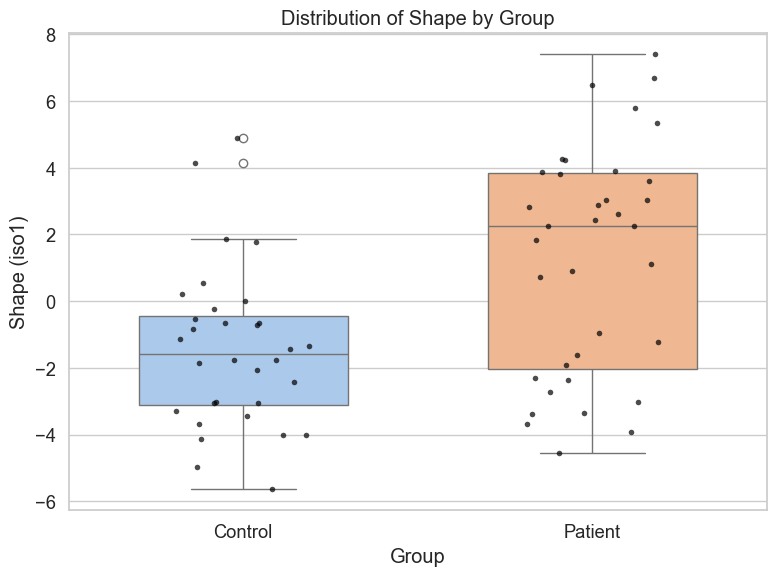

In [305]:
##########################################  boxplot  ##########################################
np.random.seed(42)  # fix the seed so there's no random jitter 

df = combined
order = ['Control','Patient']  # specify desired order
# Set a clean, publication-style aesthetic
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Category",
    y="iso1",
    data=df,
    palette="pastel",
    width=0.6,
    order=order
)

# Overlay individual points
sns.stripplot(
    x="Category",
    y="iso1",
    data=df,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7,
    order=order
)

plt.title("Distribution of Shape by Group")
plt.xlabel("Group")
plt.ylabel("Shape (iso1)")
plt.tight_layout()

#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\Plots\iso1_ctl_patient_Box_Distribution.png')
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Box_Distribution.png')

#outFileName = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\umap_remove_2\{outName}'


plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\2150691961.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category_num', y='iso1', data=df, palette='coolwarm')


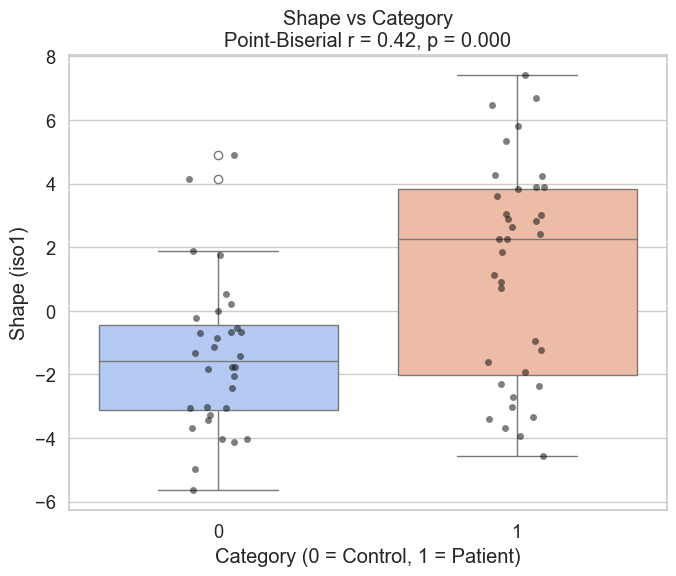

In [306]:
#########################   optional, adding point-biserail information    ############################

from scipy.stats import pointbiserialr

r, p = pointbiserialr(df['Category_num'], df['iso1'])

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.boxplot(x='Category_num', y='iso1', data=df, palette='coolwarm')
sns.stripplot(x='Category_num', y='iso1', data=df, color='black', jitter=True, alpha=0.5)

plt.xlabel('Category (0 = Control, 1 = Patient)')
plt.ylabel("Shape (iso1)")
plt.title(f'Shape vs Category\nPoint-Biserial r = {r:.2f}, p = {p:.3f}')
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\1346333915.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_L["side"] = "L"
C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\1346333915.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_R["side"] = "R"


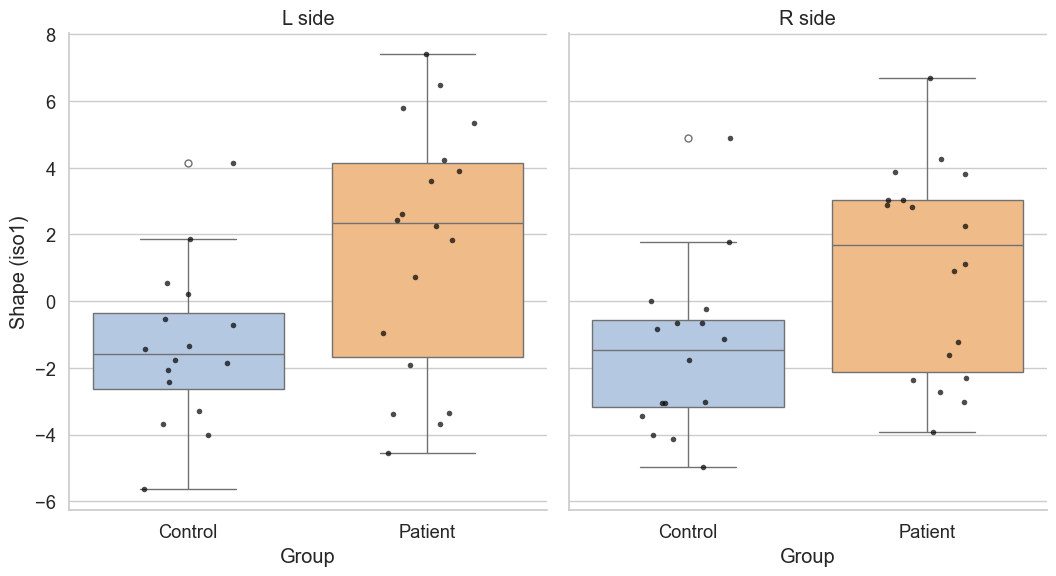

In [307]:
order = ['Control', 'Patient']
#custom_palette = {
#    'Control': '#1f77b4',  # blue
#    'Patient': '#ff7f0e'   # orange
#}
custom_palette = {
    'Control': '#aec7e8',  # pastel blue
    'Patient': '#ffbb78'   # pastel orange
}

combined_L["side"] = "L"
combined_R["side"] = "R"
df_both = pd.concat([combined_L, combined_R])

sns.set(style="whitegrid", font_scale=1.2)

g = sns.catplot(
    data=df_both,
    x="Category",
    y="iso1",
    hue="Category",
    col="side",
    kind="box",
    palette=custom_palette,
    order=order,
    height=6,
    aspect=0.9
)

# Overlay points
for ax, side in zip(g.axes[0], ["L", "R"]):
    sns.stripplot(
        data=df_both[df_both["side"] == side],
        x="Category",
        y="iso1",
        color="black",
        size=4,
        jitter=0.2,
        alpha=0.7,
        order=order,
        ax=ax
    )

g.set_axis_labels("Group", "Shape (iso1)")
g.set_titles("{col_name} side")
plt.tight_layout()

# Save if needed
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Box_Hem_Distribution.png')

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\2665292574.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_L["side"] = "L"
C:\Users\joyca\AppData\Local\Temp\ipykernel_210424\2665292574.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_R["side"] = "R"


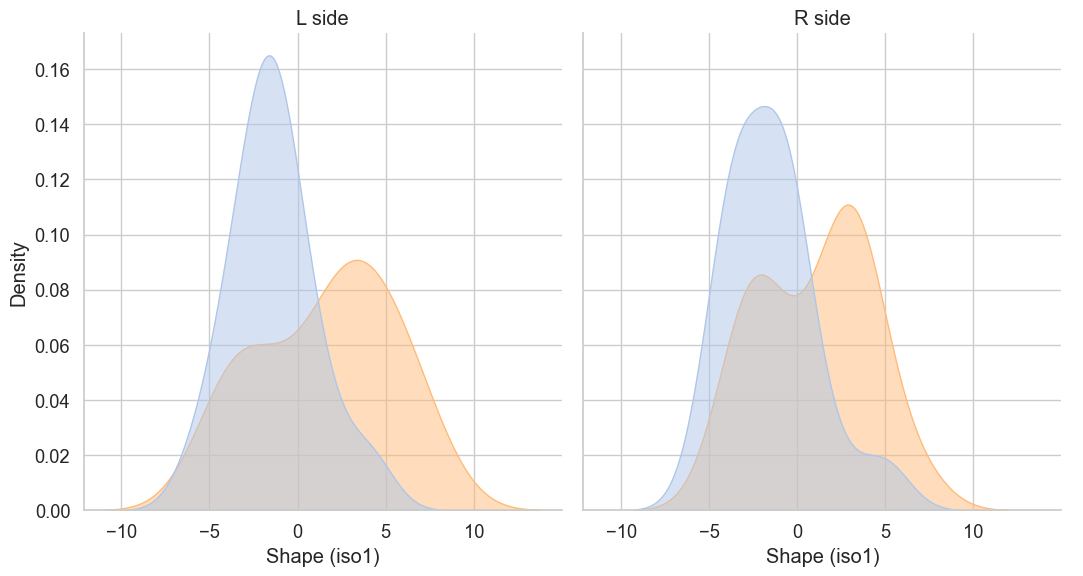

In [308]:
order = ['Control', 'Patient']
custom_palette = {
    'Control': '#aec7e8',  # pastel blue
    'Patient': '#ffbb78'   # pastel orange
}

# Add hemisphere labels
combined_L["side"] = "L"
combined_R["side"] = "R"
df_both = pd.concat([combined_L, combined_R])

sns.set(style="whitegrid", font_scale=1.2)

# Create FacetGrid by hemisphere
g = sns.FacetGrid(df_both, col="side", height=6, aspect=0.9)

# Map kdeplot with controlled hue order and colors
g.map_dataframe(
    sns.kdeplot,
    x="iso1",
    hue="Category",
    hue_order=order,
    palette=custom_palette,
    common_norm=False,
    fill=True,
    alpha=0.5
)

# Titles and labels
g.set_axis_labels("Shape (iso1)", "Density")
g.set_titles("{col_name} side")
g.add_legend()

plt.tight_layout()

# Optional save
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Density_Hem_Distribution.png')

plt.show()


In [309]:
#################################################  WIP  ################################################

#############################  comparing patients vs. controls, with covariates  ##############################
## use GLM, if Gaussian  ##
model = smf.ols("shape_measure ~ group + age + sex", data=df).fit()
print(model.summary())

## use rank-based ANCOVA, if non-Gaussian  ## 


############################  correlation between patients and controls, with covariates  ##############################
## use partial correlation, for plots ##


PatsyError: Error evaluating factor: NameError: name 'age' is not defined
    shape_measure ~ group + age + sex
                            ^^^